In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

DB_PATH = "../outputs/olist.db"
conn    = sqlite3.connect(DB_PATH)

print("Libraries loaded. Prophet ready.")

Libraries loaded. Prophet ready.


In [2]:
# Load monthly revenue data
df_ts = pd.read_sql("""
    SELECT
        DATE(order_purchase_timestamp) AS ds,
        SUM(p.payment_value)           AS y
    FROM orders   o
    JOIN payments p ON o.order_id = p.order_id
    WHERE order_purchase_timestamp IS NOT NULL
    AND   order_status = 'delivered'
    GROUP BY DATE(order_purchase_timestamp)
    ORDER BY ds
""", conn)

conn.close()

# Convert to datetime
df_ts['ds'] = pd.to_datetime(df_ts['ds'])
df_ts['y']  = df_ts['y'].astype(float)

# Remove last month (incomplete data)
df_ts = df_ts[df_ts['ds'] < '2018-09-01']

print(f"Date range: {df_ts['ds'].min().date()} to {df_ts['ds'].max().date()}")
print(f"Total days: {len(df_ts)}")
print(f"Avg daily revenue: ${df_ts['y'].mean():,.2f}")
print(f"Max daily revenue: ${df_ts['y'].max():,.2f}")
print(f"\nFirst 5 rows:")
print(df_ts.head().to_string(index=False))

Date range: 2016-10-03 to 2018-08-29
Total days: 611
Avg daily revenue: $25,238.15
Max daily revenue: $175,250.94

First 5 rows:
        ds       y
2016-10-03  559.53
2016-10-04 9821.42
2016-10-05 7209.50
2016-10-06 6733.52
2016-10-07 6832.76


12:33:17 - cmdstanpy - INFO - Chain [1] start processing
12:33:19 - cmdstanpy - INFO - Chain [1] done processing


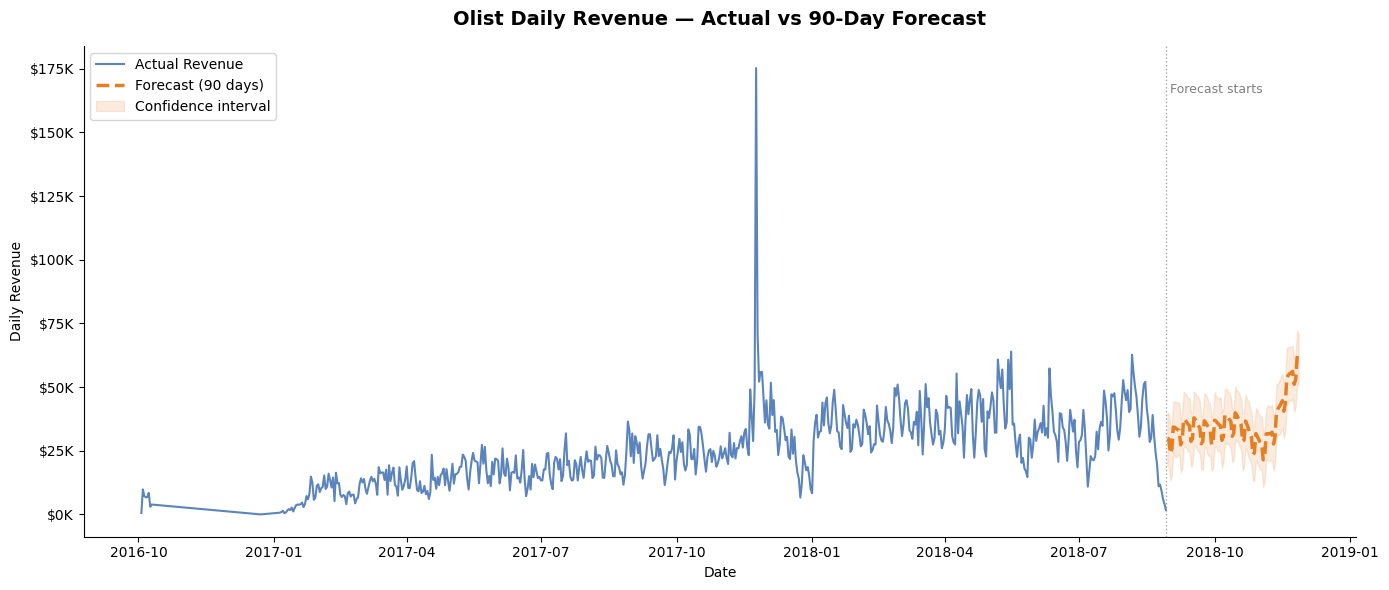

Avg forecast daily revenue: $35,582.95
Total forecast 90-day revenue: $3,202,465.23


In [3]:
# Build and train the Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(df_ts)

# Forecast 90 days into the future
future    = model.make_future_dataframe(periods=90)
forecast  = model.predict(future)

# Plot the forecast
fig, ax = plt.subplots(figsize=(14, 6))

# Actual values
ax.plot(df_ts['ds'], df_ts['y'],
        color='#3266ad', linewidth=1.5,
        label='Actual Revenue', alpha=0.8)

# Forecasted values
forecast_only = forecast[forecast['ds'] > df_ts['ds'].max()]
ax.plot(forecast_only['ds'], forecast_only['yhat'],
        color='#E67E22', linewidth=2.5,
        linestyle='--', label='Forecast (90 days)')

# Confidence interval
ax.fill_between(forecast_only['ds'],
                forecast_only['yhat_lower'],
                forecast_only['yhat_upper'],
                alpha=0.15, color='#E67E22',
                label='Confidence interval')

# Forecast start line
ax.axvline(x=df_ts['ds'].max(),
           color='gray', linewidth=1,
           linestyle=':', alpha=0.7)
ax.text(df_ts['ds'].max(), ax.get_ylim()[1] * 0.9,
        ' Forecast starts', fontsize=9, color='gray')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))
ax.set_xlabel('Date')
ax.set_ylabel('Daily Revenue')
ax.set_title('Olist Daily Revenue — Actual vs 90-Day Forecast',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/chart7_revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary numbers
avg_forecast = forecast_only['yhat'].mean()
total_90day  = forecast_only['yhat'].sum()
print(f"Avg forecast daily revenue: ${avg_forecast:,.2f}")
print(f"Total forecast 90-day revenue: ${total_90day:,.2f}")

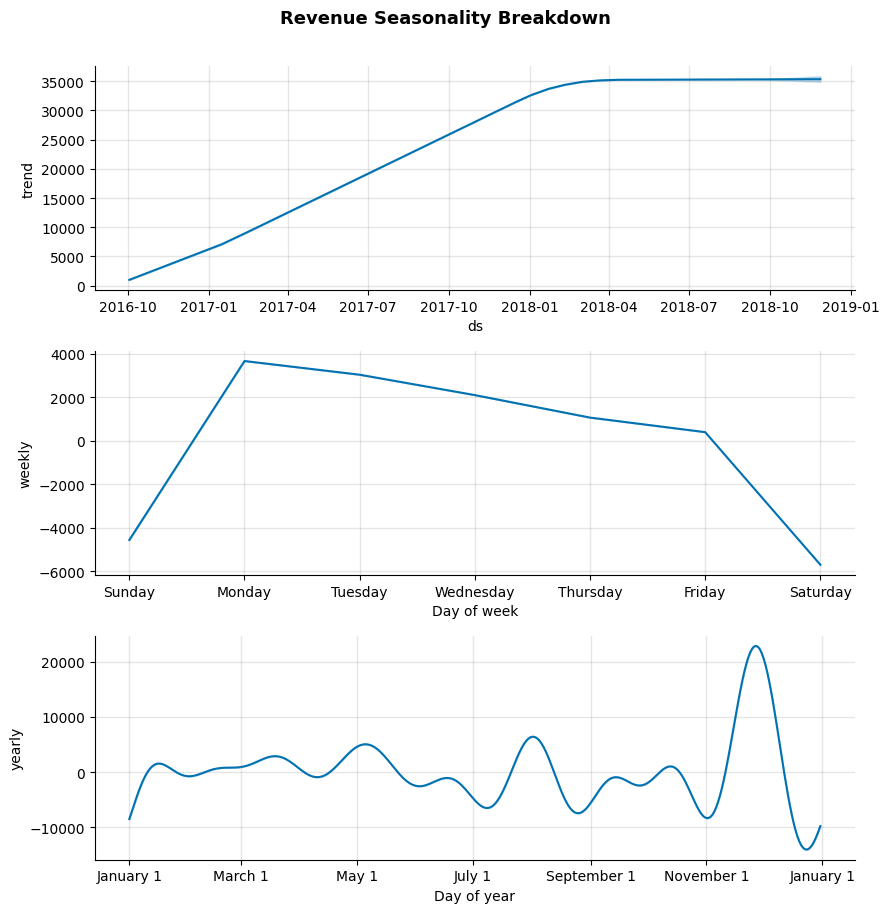

=== PHASE 5 COMPLETE — FORECASTING BRIEF ===

KEY FINDINGS:

1. BLACK FRIDAY SPIKE
   Nov 2017 peak: $175,250 in a single day
   7x higher than daily average of $25,238
   Same spike forecast for Nov 2018

2. 90-DAY REVENUE FORECAST
   Projected total:     $3,202,465
   Projected daily avg: $35,583
   Growth vs historical: +41%

3. WEEKLY PATTERN
   Check seasonality chart — identifies which
   days of the week drive highest order volume

RECOMMENDATIONS:

R1. Pre-position logistics capacity 2 weeks before
    November — Black Friday will spike volume 7x
    and current infrastructure cannot handle it
    without the 18% late delivery rate recurring.

R2. Use the 90-day forecast to plan seller inventory
    for Health & Beauty and Watches — top revenue
    categories that will see the highest demand.

R3. Staff customer support for Nov-Dec surge —
    late delivery complaints spike with volume.


In [4]:
# Seasonality breakdown
fig2 = model.plot_components(forecast)
plt.suptitle('Revenue Seasonality Breakdown',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/chart8_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== PHASE 5 COMPLETE — FORECASTING BRIEF ===")
print()
print("KEY FINDINGS:")
print()
print("1. BLACK FRIDAY SPIKE")
print("   Nov 2017 peak: $175,250 in a single day")
print("   7x higher than daily average of $25,238")
print("   Same spike forecast for Nov 2018")
print()
print("2. 90-DAY REVENUE FORECAST")
print(f"   Projected total:     $3,202,465")
print(f"   Projected daily avg: $35,583")
print(f"   Growth vs historical: +41%")
print()
print("3. WEEKLY PATTERN")
print("   Check seasonality chart — identifies which")
print("   days of the week drive highest order volume")
print()
print("RECOMMENDATIONS:")
print()
print("R1. Pre-position logistics capacity 2 weeks before")
print("    November — Black Friday will spike volume 7x")
print("    and current infrastructure cannot handle it")
print("    without the 18% late delivery rate recurring.")
print()
print("R2. Use the 90-day forecast to plan seller inventory")
print("    for Health & Beauty and Watches — top revenue")
print("    categories that will see the highest demand.")
print()
print("R3. Staff customer support for Nov-Dec surge —")
print("    late delivery complaints spike with volume.")